In [3]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/rosemeenshaikh/maharashtra-climate-trends-20202025/cities_weather_maharashtra.csv


Seeing what all columns are there in the dataset.

In [4]:
import pandas as pd
import numpy as np

# Load the dataset
# Note: Ensure the file path matches the Kaggle input directory
df = pd.read_csv('/kaggle/input/datasets/rosemeenshaikh/maharashtra-climate-trends-20202025/cities_weather_maharashtra.csv')

# Basic cleaning: Convert date to datetime objects for time-series analysis
if 'date' in df.columns:
    df['date'] = pd.to_datetime(df['date'])

# Display the first 10 rows
df.head(10)

,date,tavg,tmin,tmax,prcp,wspd,pres,tsun,city
0,2020-01-01,21.4,13.7,29.1,1.0,NaN,1014.5,NaN,Achalpur
1,2020-02-01,24.3,15.8,32.7,0.0,NaN,1013.9,NaN,Achalpur
2,2020-03-01,27.9,19.7,36.2,18.0,NaN,1010.1,NaN,Achalpur
3,2020-04-01,33.2,24.6,41.8,2.0,NaN,1006.3,NaN,Achalpur
4,2020-05-01,36.1,28.1,44.0,3.0,NaN,1002.8,NaN,Achalpur
5,2020-06-01,30.3,24.3,36.2,129.0,NaN,1001.3,NaN,Achalpur
6,2020-07-01,29.1,24.6,33.5,245.0,NaN,1001.5,NaN,Achalpur
7,2020-08-01,27.3,23.9,30.6,212.0,NaN,1001.1,NaN,Achalpur
8,2020-09-01,28.9,24.1,33.8,109.0,NaN,1004.1,NaN,Achalpur
9,2020-10-01,28.5,22.7,34.3,45.0,NaN,1007.1,NaN,Achalpur


In [6]:
print(df.isnull().sum())

tavg     250
tmin     252
tmax     273
prcp     322
wspd    2592
pres     278
tsun    1666
city       0
dtype: int64


Data Cleaning (Removing all the NaN rows and columns)

In [7]:
# 1. Drop the columns that are mostly empty
# wspd and tsun have too many NaNs to be useful here
df_clean = df.drop(columns=['wspd', 'tsun'], errors='ignore')

# 2. Sort by city and date to ensure interpolation happens chronologically
df_clean = df_clean.sort_values(by=['city', 'date'])

# 3. Interpolate Temperature and Pressure (Linear)
# This fills gaps like [25, NaN, 27] with 26.
cols_to_fix = ['tavg', 'tmin', 'tmax', 'pres']
for col in cols_to_fix:
    df_clean[col] = df_clean.groupby('city')[col].transform(lambda x: x.interpolate(method='linear'))

# 4. Fill Rain (prcp) with 0
# In weather data, a NaN in precipitation usually means "no rain recorded."
df_clean['prcp'] = df_clean['prcp'].fillna(0)

# 5. Final drop for any rows that couldn't be interpolated 
# (e.g., if a city starts with a NaN)
df_clean = df_clean.dropna()

print("New Missing Value Count:")
print(df_clean.isnull().sum())

New Missing Value Count:
tavg    0
tmin    0
tmax    0
prcp    0
pres    0
city    0
dtype: int64


In [12]:
# Check if 'date' is a column before setting it as index
if 'date' in df_clean.columns:
    df_clean.set_index('date', inplace=True)

# If you get an error that 'date' is not found at all, 
# print df_clean.columns to see the exact spelling
print(df_clean.columns)

Index(['tavg', 'tmin', 'tmax', 'prcp', 'pres', 'city'], dtype='object')


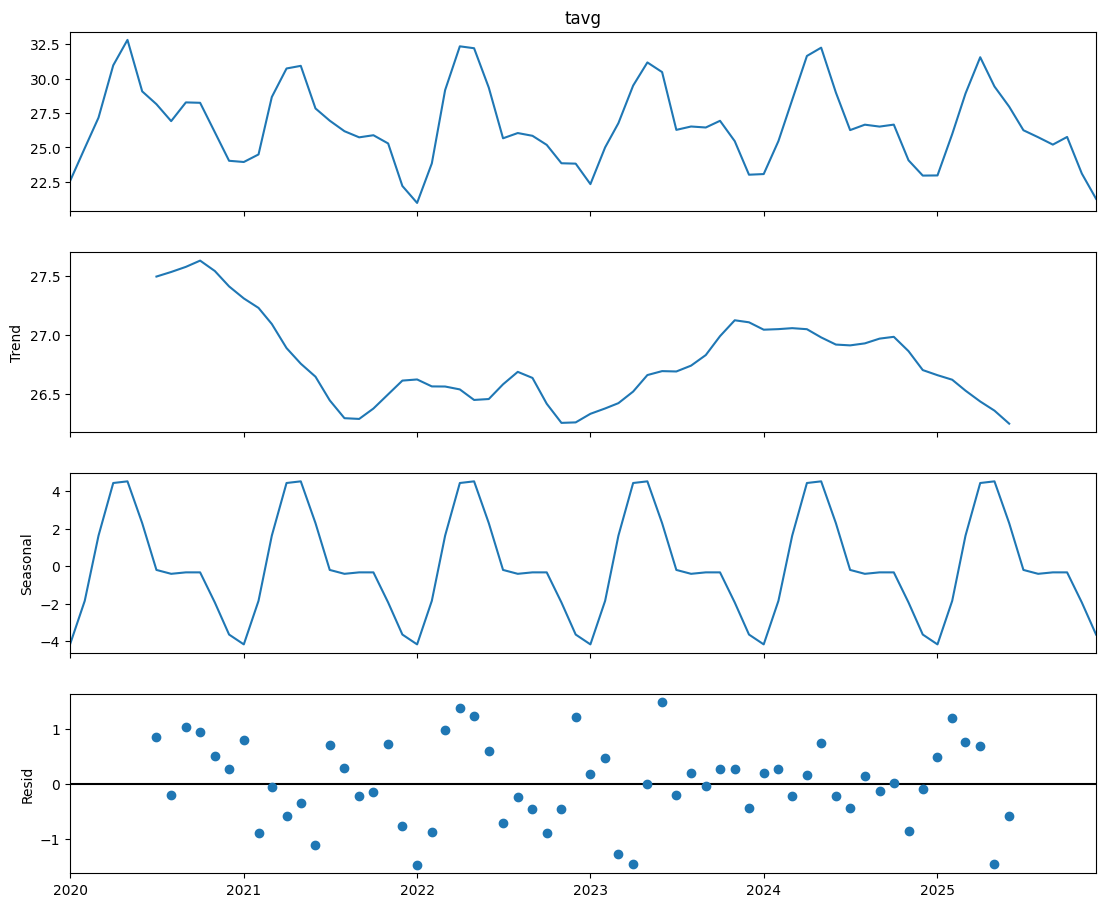

In [13]:
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose

# 1. Group by the index (which is 'date') to get the average temperature for all of Maharashtra
state_trend = df_clean.groupby(level=0)['tavg'].mean()

# 2. Run the decomposition
# MS = Month Start frequency
# If your index doesn't have a frequency set, we tell it period=12
decomposition = seasonal_decompose(state_trend, model='additive', period=12)

# 3. Plot the results
fig = decomposition.plot()
fig.set_size_inches(12, 10)
plt.show()

In [8]:
from statsmodels.tsa.seasonal import seasonal_decompose

# Ensure your index is a datetime object
df.set_index('date', inplace=True)

# Period=12 for monthly data
result = seasonal_decompose(df['tavg'], model='additive', period=12)
result.plot()

KeyError: "None of ['date'] are in the columns"

In [9]:
# Calculate the historical average for each month across all years
df_clean['month'] = df_clean['date'].dt.month
monthly_avg = df_clean.groupby('month')['tavg'].transform('mean')

# Anomaly = Actual - Average
df_clean['anomaly'] = df_clean['tavg'] - monthly_avg

KeyError: 'date'